# Проект для классифкации комментариев

## Цель проекта: создания модели, для предсказания положительного или отрицательного комментария.

## План работы:
- #### Загрузка данных;
- #### Анализ исходного датасета;
- #### Предварительная обработка датасета;
- #### Построение и обучение моделей;
- #### Оценка качества моделей;
- #### Подведение итогов;

### Загрузка необходимых библиотек

In [5]:
!pip install pymystem3

In [1]:
import re
import nltk
import warnings
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf

from pickle import dump
from nltk.corpus import stopwords
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.model_selection import train_test_split, GridSearchCV
from tensorflow import keras
from tensorflow.keras.preprocessing import text, sequence
from pymystem3 import Mystem

warnings.filterwarnings('ignore')
%matplotlib inline

In [46]:
nltk.download("stopwords")

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Matwei\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


True

## Загрузка данных

In [2]:
# Путь до фойла с данными
path_file_txt = './dataset.txt'

In [3]:
def creat_df(path_file_txt: str) -> pd.DataFrame:
    '''
    Создаёт датасет из текстового файла(.txt).

    Parameters
    ----------
    path_file_txt : string
        Путь до файла из которого будет создаваться датасет.

    Returns
    -------
    pd.DataFrame
        Готовый датасет.
    '''
    data_list = []
    with open(path_file_txt, encoding = 'utf-8') as file:
        for line in file:
            labels = line.split()[0]
            text = line[len(labels)+1:].strip()
            labels = labels.split(",")
            mask = [1 if "__label__NORMAL" in labels else 0,
                    1 if "__label__INSULT" in labels else 0,
                    1 if "__label__THREAT" in labels else 0,
                    1 if "__label__OBSCENITY" in labels else 0]
            data_list.append((text, *mask))
    return pd.DataFrame(data_list, columns=["comment", "normal", "insult", "threat", "obscenity"])

In [4]:
# Создания датасета
df = creat_df(path_file_txt)
df

,comment,normal,insult,threat,obscenity
0,скотина! что сказать,0,1,0,0
1,я сегодня проезжала по рабочей и между домами ...,1,0,0,0
2,очередной лохотрон. зачем придумывать очередно...,1,0,0,0
3,"ретро дежавю ... сложно понять чужое сердце , ...",1,0,0,0
4,а когда мы статус агрогородка получили?,1,0,0,0
...,...,...,...,...,...
248285,правильно всё по пять (5)...,1,0,0,0
248286,ёбанные нубы заходите на сервер мой ник _creep...,0,1,0,0
248287,а у меня наверное рекорд в 1962 году в училище...,1,0,0,0
248288,спасибо всем большое),1,0,0,0


## Анализ исходного датасета

In [186]:
df

,comment,normal,insult,threat,obscenity
0,скотина! что сказать,0,1,0,0
1,я сегодня проезжала по рабочей и между домами ...,1,0,0,0
2,очередной лохотрон. зачем придумывать очередно...,1,0,0,0
3,"ретро дежавю ... сложно понять чужое сердце , ...",1,0,0,0
4,а когда мы статус агрогородка получили?,1,0,0,0
...,...,...,...,...,...
248285,правильно всё по пять (5)...,1,0,0,0
248286,ёбанные нубы заходите на сервер мой ник _creep...,0,1,0,0
248287,а у меня наверное рекорд в 1962 году в училище...,1,0,0,0
248288,спасибо всем большое),1,0,0,0


### Описание признаков
- ##### comment | комментарий | объективный признак | строковое значение
- ##### normal | комментарий положительный | целевая переменная | бинарная 
- ##### insult | комментарий с оскорблением | целевая переменная | бинарная 
- ##### threat | комментарий с угрозой | целевая переменная | бинарная 
- ##### obscenity | комментарий с непристойностью | целевая переменная | бинарная 

Датасет состоит из комментариев и его классификации. У комментария может быть один из 4 вида классификации:
* ##### положительный;
* ##### с содержанием оскорблениея;
* ##### с содержанием угрозы;
* ##### с содержанием непристойности.

In [23]:
# Размерность датасета
df.shape

(248290, 5)

Датасет имеет 248290 записи и 5 признаков.

In [22]:
# Информация о признаках находящимся в датасете 
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 248290 entries, 0 to 248289
Data columns (total 5 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   comment    248290 non-null  object
 1   normal     248290 non-null  int64 
 2   insult     248290 non-null  int64 
 3   threat     248290 non-null  int64 
 4   obscenity  248290 non-null  int64 
dtypes: int64(4), object(1)
memory usage: 9.5+ MB


Как можно увидеть выше, в датасете отсутствуют пропущенные значения. Признак 'comment' имеет тип данных object, а остальные тип данных int64.

In [312]:
df['comment'].str.len().min()

np.int64(2)

In [310]:
df[df['comment'].str.len() == df['comment'].str.len().min()]

,comment,normal,insult,threat,obscenity
9765,рь,1,0,0,0
69639,ее,1,0,0,0
170736,го,1,0,0,0
193392,чт,1,0,0,0


Минимальный по длине комментарий имеет 2 символа.

In [313]:
df['comment'].str.len().max()

np.int64(998)

In [323]:
df[df['comment'].str.len() == df['comment'].str.len().max()].iloc[2].comment

'нас теперь фургаловском обзывают, но большинство то не вышло, наблюдали просто, а дегтярев ща по краю ездит и в акуе, полный завал, фургал профессионально пиарился, типа делал, а не делал ни хера, он своим бизнесом занимался и клево лапшу вешал на уши.. как его взяли, так сразу с правительства крысы побежали, видать, грехов до хера, он свою команду привёл, и делали что хотели, а тут указ, деньги спиздить нельзя, сейчас дегтярев разбирается. и меняет команду, возвращает людей, которые профессионалы и знают свое дело, которых фургал поувальнял, в общем дела тут веселенькие... но вроде как сдвинулось, работа пошла.. многие довольны, а фургалоиды так его оскорбляют, ужас, страшно читать, но выдержка у парня железная, он реально работает, с многочисленными проблемами.. москва помогает, выделили огромную сумму.. косяков тут не перечесть, посмотрим, надеюсь, изменится что то, инвесторы подтягиваются, с фургалом работать не хотели, видать, больше нас знали, что он за птица.. как то так вот..'

In [324]:
df[df['comment'].str.len() == df['comment'].str.len().max()].iloc[3].comment

'люди, которые голосовали в 1993 не понимали тогда, что после третьего референдума у них будет олигархи, и у них будет в 10 раз меньше экономика. они не понимали, что уже на третьем голосовании они повесят себе хомут на шею. нам же, сейчас, придется народ воспитывать не одним референдумом, а двумя, тремя. нодовцы же четко знают и понимают и они по-шагово продвигают восстановление отечества. у народа появляются вопросы, что вот это уже принято, и зачем нам голосовать? это все вопросы оттого, что люди не понимают смысла процесса. чуда не произойдет! много кратнойзарплаты 2 июля не появится. а жить надо. поэтому дальше будут осуществляться следующие шаги, которые запланировал путин - это деофшоризация, национализация и изгнание олигархов, национализация цб, национализация рубля, национализация правовой системы. а эти вопросы нодовские. их придется делать. и во второй и третий раз придется опираться на народ через конституционное собрание, референдумы, вече... вот так будут идти процессы.'

In [317]:
df[df['comment'].str.len() == df['comment'].str.len().max()]

,comment,normal,insult,threat,obscenity
69097,"напротив кпт строится бульвар или что-то еще, ...",1,0,0,0
99153,марри уокер: хэмилтон лучше шумахера и сенны л...,1,0,0,0
169210,"нас теперь фургаловском обзывают, но большинст...",0,1,0,0
188677,"люди, которые голосовали в 1993 не понимали то...",1,0,0,0


Максимальный по длине комментарий имеет 998 символов.

In [290]:
df[(df['normal'] == 0) & (df['insult'] == 0) & (df['threat'] == 0) & (df['obscenity'] == 0)]

,comment,normal,insult,threat,obscenity


Отсутствуют комментарии, которые бы не содержали ни одной классификации, то есть без классификации.

In [32]:
lst_count_classes = [df[df[comment_class] == 1].shape[0] for comment_class in ['normal', 'insult', 'threat', 'obscenity']]
print('type_comment', *[f'\n{i}    {lst_count_classes[i]}' for i in range(4)], '\nName: count, dtype: int64')

type_comment 
0    203685 
1    36826 
2    12027 
3    4261 
Name: count, dtype: int64


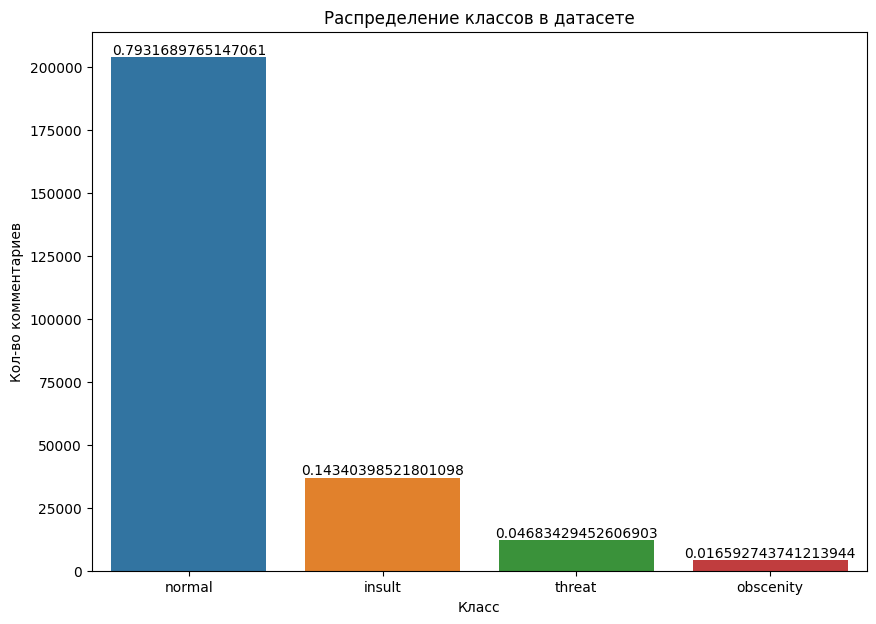

In [193]:
x = df.iloc[:,1:].sum()

plt.figure(figsize=(10,7));
ax = sns.barplot(x=x.index, y=x.values, hue=x.index)
plt.title("Распределение классов в датасете")
plt.xlabel('Класс')
plt.ylabel('Кол-во комментариев')

patch = ax.patches
labels = x.values / x.values.sum()
for rect, label in zip(patch, labels):
    height = rect.get_height()
    ax.text(rect.get_x() + rect.get_width()/2, height + 10, label, va='bottom',ha='center')

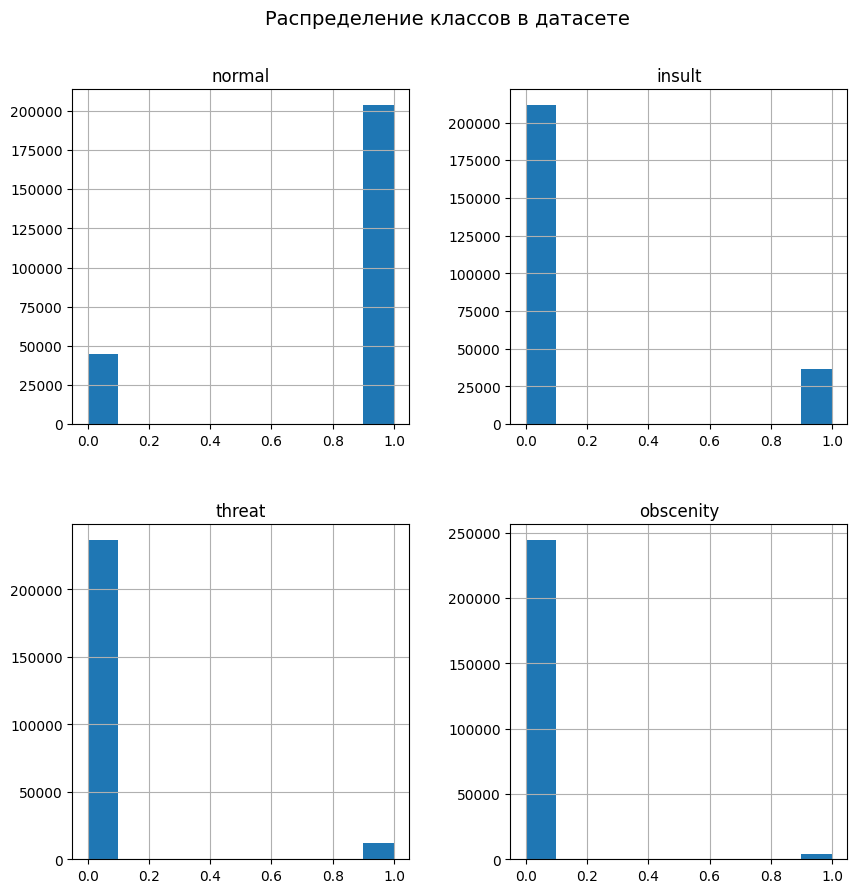

In [252]:
df.hist(ax=plt.figure(figsize = (10,10)))
plt.suptitle('Распределение классов в датасете', y=0.96, size = 14);

На графиках выше видно, что количество положительных комментариев значительно больше, чем отрицательных. Положительных комментариев составляет примерно 0.79%, а неположительных комментариев примерно 0.21%.

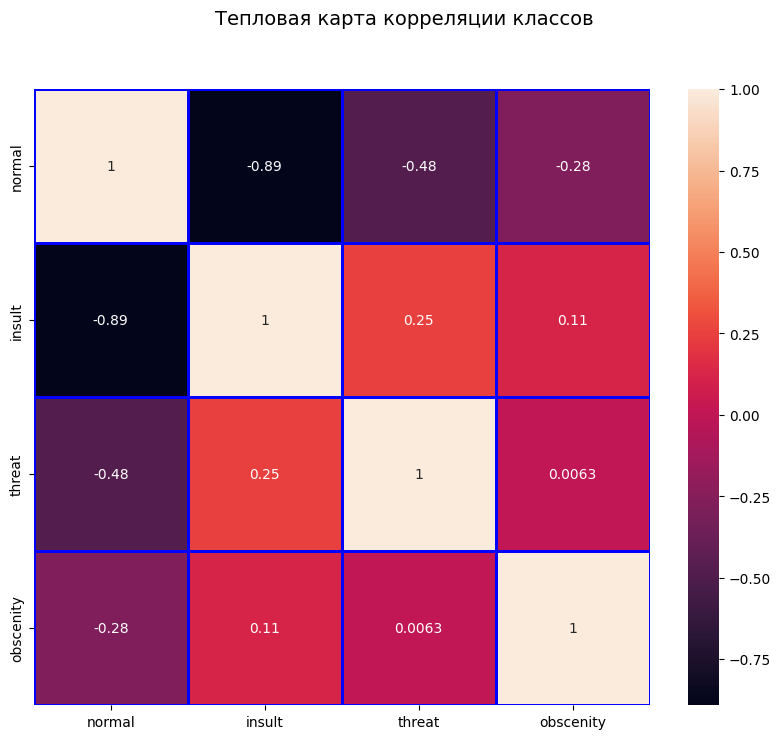

In [296]:
# heatmap for training data
fig = plt.figure(figsize = (10,8))
sns.heatmap(df.drop(['comment'], axis=1).corr(), annot=True, linewidths=0.73, linecolor='blue', square=True)
plt.suptitle('Тепловая карта корреляции классов',size = 14)
plt.show()

На тепловой карте видно, что присутствуют зависимости между классами, но их мало. Зависимости присутствуют между:
* класс _normal_ имеет обратные зависимости между всеми классами;
* класс _insult_ имеет небольшую зависимость с _threat_.

## Вывод по анализу датасета

В датасете присутствует отрицательные зависимости между положительными и отрицательными классами. 

Распределения между классами не равномерная, положительных комментариев во много раз больше, чем суммарно отрицательных(79% положительных и 21% отрицательных).

## Предварительная обработка датасета

In [5]:
class WordProcessing:
    def __init__(self):
        self.mystem = Mystem()
        self.sw = stopwords.words("russian")
    
    # Функция для предобработки текста
    def preprocess_text(self, text):
        text = text.replace('ё', 'е')
        text = re.sub('((www\.[^\s]+)|(https?://[^\s]+))', 'URL', text)
        text = re.sub('[^a-zA-Zа-яА-Я]+', ' ', text)
        text = re.sub(' +', ' ', text)
        text = text.lower()
        text = ' '.join([word for word in text.split() if word not in self.sw])
        text = ' '.join([re.sub('^[a-zA-Zа-яА-Я]{,2}$', '', word) for word in text.split()])
        return text.strip()
    
    # Лемматизация текста по строкам
    def lemmatization_dataset(self, lines_df):
        all_text = 'BR'.join(lines_df)
        lemmatization_text = ''.join(self.mystem.lemmatize(all_text))
        lemmatization_lines = lemmatization_text.split('BR')
        return lemmatization_lines

In [6]:
%%time
wordProcessing = WordProcessing()
df['clean_comment'] = df['comment'].apply(wordProcessing.preprocess_text)
df['clean_comment'] = wordProcessing.lemmatization_dataset(df['clean_comment'])
df = df[['comment', 'clean_comment', 'normal', 'insult', 'threat', 'obscenity']]

CPU times: total: 14.1 s
Wall time: 1min 7s


In [7]:
df[df['clean_comment'].str.len() == 0]

,comment,clean_comment,normal,insult,threat,obscenity
238,ч о я,,1,0,0,0
848,|) так и есть.,,1,0,0,0
1057,ну может 3-5,,1,0,0,0
1301,"да, так и есть🙂",,1,0,0,0
1447,то ли ещё будет …,,1,0,0,0
...,...,...,...,...,...,...
247458,его бы так,,1,0,0,0
247479,все 👍👍👍♥♥♥,,1,0,0,0
247686,1 и только 1,,1,0,0,0
247887,тем более 👏😆,,1,0,0,0


После обработки текста, появились комментарии у которых длина равная 0. Таких записей всего лишь 0.4%, поэтому они будут удалены.

In [9]:
df = df[df['clean_comment'].str.len() != 0]

In [15]:
df

,comment,clean_comment,normal,insult,threat,obscenity
0,скотина! что сказать,скотина сказать,0,1,0,0
1,я сегодня проезжала по рабочей и между домами ...,сегодня проезжать рабочий дом снитенко гомолыс...,1,0,0,0
2,очередной лохотрон. зачем придумывать очередно...,очередной лохотрон придумывать очередной налог...,1,0,0,0
3,"ретро дежавю ... сложно понять чужое сердце , ...",ретро дежавю сложно понимать чужой сердце лиш ...,1,0,0,0
4,а когда мы статус агрогородка получили?,статус агрогородок получили,1,0,0,0
...,...,...,...,...,...,...
248285,правильно всё по пять (5)...,правильно пять,1,0,0,0
248286,ёбанные нубы заходите на сервер мой ник _creep...,ебанные нуба заходить сервер ник creepro пвп п...,0,1,0,0
248287,а у меня наверное рекорд в 1962 году в училище...,наверное рекорд год училище коренной зуб возмо...,1,0,0,0
248288,спасибо всем большое),спасибо все большое,1,0,0,0


Так как в данных очень большой дисбаланс между классами, сделаем уменьшение самого большого класса, чтобы облегчить обучение для модели.

In [21]:
# сохраним в переменную индексы нетоксических сообщений
normal_class = df[df['normal'] > 0].index

In [16]:
# вычислим 30% сообщений из выборки
part30percent = (len(normal_class)*30)/100
part30percent

60756.3

In [17]:
# из найденных индексов выберем первые 30%
drop_part_normal_class = normal_class[:round(part30percent)]
drop_part_normal_class

Index([    1,     2,     3,     4,     5,     6,     8,     9,    10,    11,
       ...
       74616, 74617, 74618, 74619, 74620, 74622, 74623, 74625, 74626, 74627],
      dtype='int64', length=60756)

In [18]:
# Удаляем первые 60756.3(30%) строк из класса normal (не токсические сообщения)
decreased_df = df.drop(drop_part_normal_class, axis=0)

In [19]:
decreased_df

,comment,clean_comment,normal,insult,threat,obscenity
0,скотина! что сказать,скотина сказать,0,1,0,0
7,заколоть этого плешивого урода что бы крякнул ...,заколоть плешивый урод крякнуть селезень гандо...,0,1,1,0
24,долбоебы это фэйк,долбоебы это фэйк,0,1,0,0
25,"пиздаболы, сделали снимок, придумали историю и...",пиздаболы сделать снимок придумывать история п...,0,1,0,0
34,"мляяя..фомин..ты издесь умничаешь,чайка помойн...",мляяя фомин издесить умничать чайка помойный с...,0,1,0,0
...,...,...,...,...,...,...
248285,правильно всё по пять (5)...,правильно пять,1,0,0,0
248286,ёбанные нубы заходите на сервер мой ник _creep...,ебанные нуба заходить сервер ник creepro пвп п...,0,1,0,0
248287,а у меня наверное рекорд в 1962 году в училище...,наверное рекорд год училище коренной зуб возмо...,1,0,0,0
248288,спасибо всем большое),спасибо все большое,1,0,0,0


In [ ]:
x = decreased_df.iloc[:,2:].sum()

plt.figure(figsize=(10,7));
ax = sns.barplot(x=x.index, y=x.values, hue=x.index)
plt.title("Распределение классов в датасете")
plt.xlabel('Класс')
plt.ylabel('Кол-во комментариев')

patch = ax.patches
labels = round(x.values / x.values.sum() * 100)
for rect, label in zip(patch, labels):
    height = rect.get_height()
    ax.text(rect.get_x() + rect.get_width()/2, height + 10, label, va='bottom',ha='center')

## Построение и обучение моделей

### Разделение тренировочные и тестовые данные

In [22]:
# df_train, df_test = train_test_split(df.drop(['comment'], axis=1), test_size=0.2)
df_train, df_test = train_test_split(decreased_df.drop('comment', axis=1), test_size=0.2)

In [23]:
# определим тренировочные и тестовые признаки
feature_train = df_train['clean_comment'].values
feature_test = df_test['clean_comment'].values

# определим тренировочные и тестовые классы
target_train = df_train[['normal', 'insult', 'threat', 'obscenity']].values
target_test = df_test[['normal', 'insult', 'threat', 'obscenity']].values

In [24]:
print("Тренировочные данные:\n", feature_train[:3], 
      "\n\n\nТестовые данные:\n", feature_test[:3], 
      "\n\n\nТренировочные классы:\n", target_train[:3], 
      "\n\n\nТестовые классы:\n", target_test[:3], sep='')

Тренировочные данные:
['настоящий герой умнеца'
 'соль уксус храниться отлично лишь доводить кипения'
 'одно пустой пиздобольльство инет телефон отрывать стрелка хреновый улица никто язык жопе']


Тестовые данные:
['моей любимый племянница юленька лехтман день юбилей такой слово высказывать любить сам знать море счастие любовь ты дорогой твой тетя'
 'знаю чей мысль лутин доба это подумать' 'саду расти абрикос урале']


Тренировочные классы:
[[1 0 0 0]
 [1 0 0 0]
 [0 1 0 0]]


Тестовые классы:
[[1 0 0 0]
 [1 0 0 0]
 [1 0 0 0]]


In [25]:
max_features = 30000
maxlen = 300

In [26]:
# Обучение токенайзера
tokenizer = text.Tokenizer(num_words=max_features)
tokenizer.fit_on_texts(list(feature_train)+list(feature_test))

In [27]:
# Разделение данных на токены
token_feature_train = tokenizer.texts_to_sequences(feature_train)
token_feature_test = tokenizer.texts_to_sequences(feature_test)

In [28]:
# Приведение данных к одной размерности
feature_train = sequence.pad_sequences(token_feature_train, maxlen=maxlen)
feature_test = sequence.pad_sequences(token_feature_test, maxlen=maxlen)

### LSTM-модель

Долгая краткосрочная память (Long short-term memory; LSTM) – особая разновидность архитектуры рекуррентных нейронных сетей, способная к обучению долговременным зависимостям.

In [151]:
# Постороение модели
lstm_model = tf.keras.Sequential([
    tf.keras.layers.InputLayer(shape=(maxlen,), name='input_layer'),
    tf.keras.layers.Embedding(max_features, maxlen, name='embedding'),
    tf.keras.layers.LSTM(50, return_sequences=True, name='lstm'),
    tf.keras.layers.GlobalMaxPooling1D(name='global_max_pooling_1d'),
    tf.keras.layers.Dropout(0.4, name='dropout_1'),
    tf.keras.layers.Dense(100, activation='leaky_relu', name='dense_1'),
    tf.keras.layers.Dropout(0.4, name='dropout_2'),
    tf.keras.layers.Dense(4, activation='softmax', name='dense_2')
], name='lstm_model')

In [153]:
# Компиляция моедли
lstm_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy', 'precision', 'recall', 'f1_score'])

In [155]:
lstm_model.summary()

Model: "lstm_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding (Embedding)                │ (None, 300, 300)            │       9,000,000 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm (LSTM)                          │ (None, 300, 50)             │          70,200 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_max_pooling_1d                │ (None, 50)                  │               0 │
│ (GlobalMaxPooling1D)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 50)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 100)                 │           5,100 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 100)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 4)                   │             404 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 9,075,704 (34.62 MB)

 Trainable params: 9,075,704 (34.62 MB)

 Non-trainable params: 0 (0.00 B)

In [157]:
history = lstm_model.fit(feature_train, target_train, epochs=5, batch_size=32, validation_split=0.1)

Epoch 1/5
4194/4194 ━━━━━━━━━━━━━━━━━━━━ 636s 151ms/step - accuracy: 0.9144 - f1_score: 0.6252 - loss: 0.1427 - precision: 0.9288 - recall: 0.8750 - val_accuracy: 0.9438 - val_f1_score: 0.7844 - val_loss: 0.0845 - val_precision: 0.9583 - val_recall: 0.9129
Epoch 2/5
4194/4194 ━━━━━━━━━━━━━━━━━━━━ 624s 149ms/step - accuracy: 0.9444 - f1_score: 0.7936 - loss: 0.0824 - precision: 0.9612 - recall: 0.9146 - val_accuracy: 0.9460 - val_f1_score: 0.7926 - val_loss: 0.0807 - val_precision: 0.9605 - val_recall: 0.9150
Epoch 3/5
4194/4194 ━━━━━━━━━━━━━━━━━━━━ 625s 149ms/step - accuracy: 0.9528 - f1_score: 0.8210 - loss: 0.0653 - precision: 0.9698 - recall: 0.9247 - val_accuracy: 0.9469 - val_f1_score: 0.7748 - val_loss: 0.0874 - val_precision: 0.9590 - val_recall: 0.9139
Epoch 4/5
4194/4194 ━━━━━━━━━━━━━━━━━━━━ 671s 160ms/step - accuracy: 0.9583 - f1_score: 0.8391 - loss: 0.0532 - precision: 0.9763 - recall: 0.9313 - val_accuracy: 0.9409 - val_f1_score: 0.7843 - val_loss: 0.0993 - val_precision: 

## Оценка качества модели

In [159]:
precision = history.history['precision']
val_precision = history.history['val_precision']

In [160]:
recall = history.history['recall']
val_recall = history.history['val_recall']

In [161]:
loss = history.history['loss']
val_loss = history.history['val_loss']

In [162]:
epochs = range(len(precision))

In [163]:
len_f1_score = len(precision)

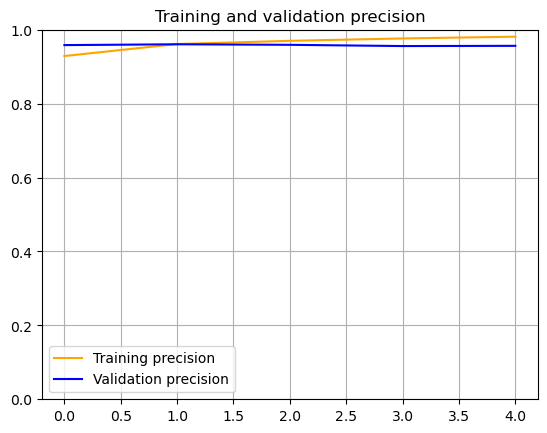

In [164]:
plt.plot(epochs, precision, 'orange', label='Training precision')
plt.plot(epochs, val_precision, 'blue', label='Validation precision')
plt.title('Training and validation precision')
plt.legend(loc=0)
plt.grid(True)
plt.gca().set_ylim(0,1)

plt.show()

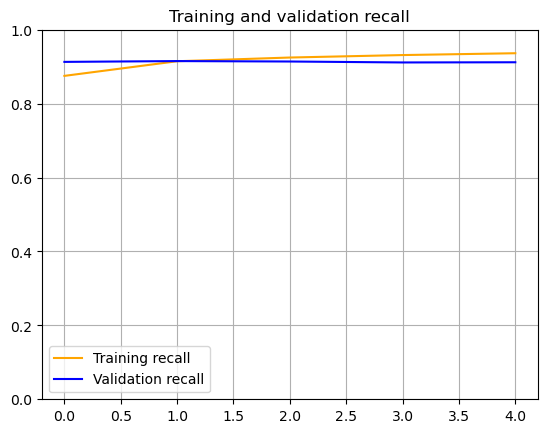

In [165]:
plt.plot(epochs, recall, 'orange', label='Training recall')
plt.plot(epochs, val_recall, 'blue', label='Validation recall')
plt.title('Training and validation recall')
plt.legend(loc=0)
plt.grid(True)
plt.gca().set_ylim(0,1)

plt.show()

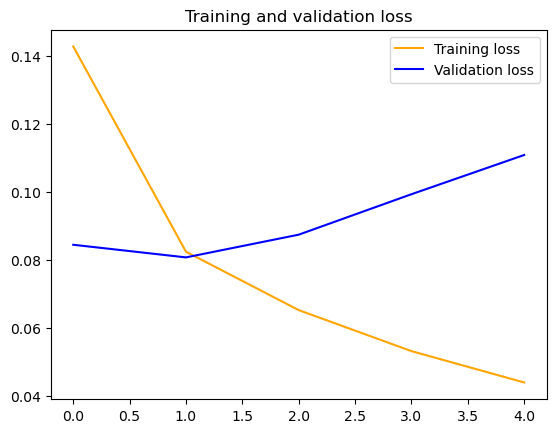

<Figure size 640x480 with 0 Axes>

In [166]:
plt.plot(epochs, loss, 'orange', label='Training loss')
plt.plot(epochs, val_loss, 'blue', label='Validation loss')
plt.title('Training and validation loss')
plt.legend(loc=0)
plt.figure()

plt.show()

In [167]:
predictions = lstm_model.predict(feature_test)

1165/1165 ━━━━━━━━━━━━━━━━━━━━ 35s 30ms/step


In [168]:
np.set_printoptions(precision=8, suppress=True)

In [169]:
predictions

array([[1.        , 0.        , 0.        , 0.        ],
       [0.99998903, 0.0000097 , 0.00000032, 0.00000094],
       [1.        , 0.        , 0.        , 0.        ],
       ...,
       [0.9999999 , 0.00000012, 0.        , 0.        ],
       [0.99494344, 0.00449873, 0.00036364, 0.00019412],
       [0.        , 0.9996092 , 0.00024099, 0.00014988]], dtype=float32)

In [170]:
predictions = np.argmax(predictions, axis=1)

In [171]:
predictions = predictions.flatten()

In [172]:
print(classification_report(np.argmax(target_test, axis=1), predictions))

              precision    recall  f1-score   support

           0       0.96      0.98      0.97     28255
           1       0.89      0.83      0.86      7402
           2       0.66      0.75      0.70      1148
           3       0.64      0.68      0.66       468

    accuracy                           0.94     37273
   macro avg       0.79      0.81      0.80     37273
weighted avg       0.94      0.94      0.94     37273



### Сохранение модели

In [189]:
with open('lstm_model.pkl', 'wb') as f:
    dump(lstm_model, f)

### Сохранение токенайзера

In [192]:
with open('tokenizer.pkl', 'wb') as f:
    dump(tokenizer, f)

## Краткий вывод по модели

После обучение модели, была проведена оценка качества модели. Модель показала хорошие результаты, даже с классом obscenity(непристойность) показала хорошие рузельтаты, учитывая процент количество данных этого класса в датасете(2%).
Поэтому модель будет взята для дальнейшей работы с ней.

# Подведение итогов

Подводя итоги, были выполнены все шаги планы, а именно:
- Загрузка данных;
- Анализ исходного датасета;
- Предварительная обработка датасета;
- Построение и обучение моделей;
- Оценка качества модели.
  
Датасет был не равномерно распределён по классам, больше всего было класса normal(положительные). 

После предобработки датасета, появились записи с пустыми значениями, которые были удалены.

Из-за сильно дисбаланс в классах, было предпринято решение убрать 30% класса normal(положительные), чтобы облегчить обучение модели.

Была построена модель долгой краткосрочной памяти (LSTM).

После обучение, была произведена оценка качество модели и выявленно хорошие результаты на предсказание всех классов.